!pip install fluprodia tespy #convert this cell to code the first time you run to install the packages

## Parameters

In [6]:
wf="R290"
eta_s=0.8
%load_ext autoreload
%autoreload 2
enable_fluid_diagrams=True
ac_evaporator_range = (10,16,1) # min, max, step
ac_condenser_range = (45,64,3) # min, max, step
hp_evaporator_range = (-30,0,6) # min, max, step
hp_condenser_range = (31,32,1) # min, max, step

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Regular Air Conditioner for comparison

(<Axes: title={'center': 'Coefficient of Performance'}, xlabel='Evaporation Temperature (°C)', ylabel='Condensation Temperature (°C)'>,
 <Figure size 640x480 with 2 Axes>)

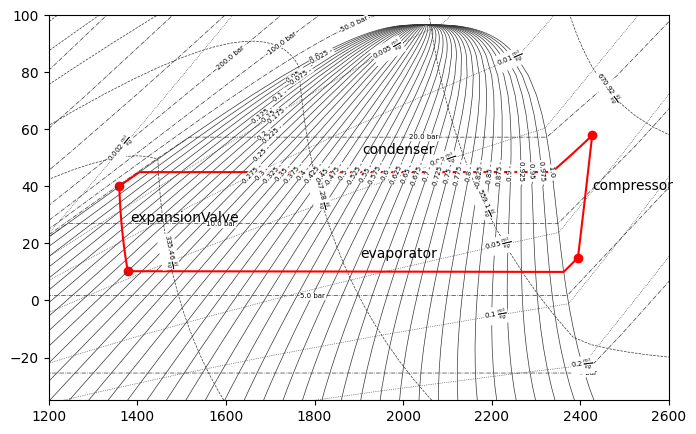

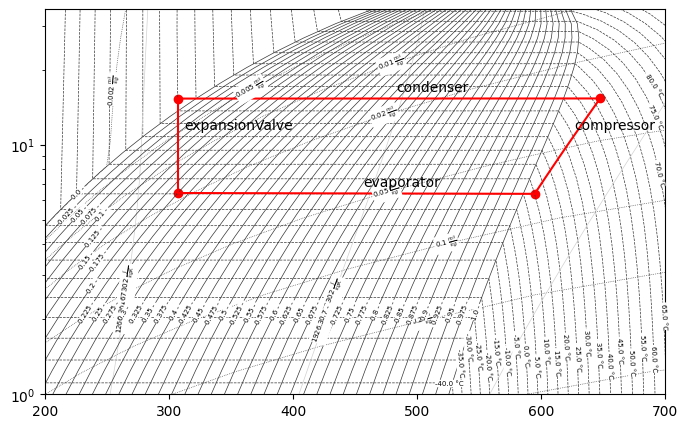

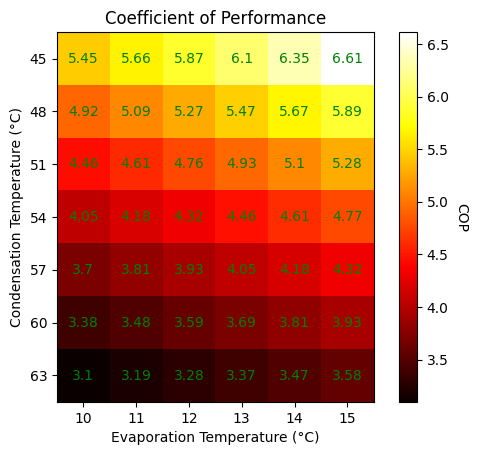

In [7]:
from HaierAirConditioner import AirConditionerStudy

regular_AC = AirConditionerStudy(working_fluid=wf, Q_in=8e3
                                ).set_boundary_conditions(T_cond=45, T_evap=10).solve()
if enable_fluid_diagrams:
    regular_AC.plot_ts_diag("output/regular_AC_ts_diagram", x_min=1200, x_max=2600, y_min=-35, y_max=100)
    regular_AC.plot_logph_diag("output/regular_AC_logph_diagram", x_min = 200, x_max=700, y_min=1, y_max=35
                               )

regular_efficiency_matrix = regular_AC.efficiency_matrix(ac_evaporator_range, ac_condenser_range)
regular_AC.plot_efficiency("output/regular_AC_efficiency_matrix", ac_evaporator_range, ac_condenser_range, regular_efficiency_matrix)



# Air Conditioner with Energy Recovery

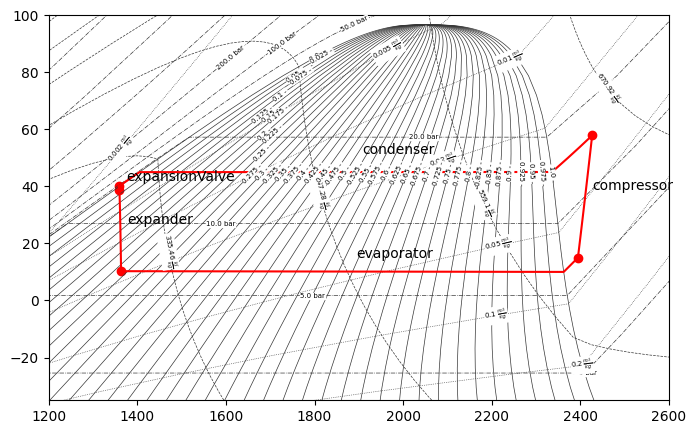

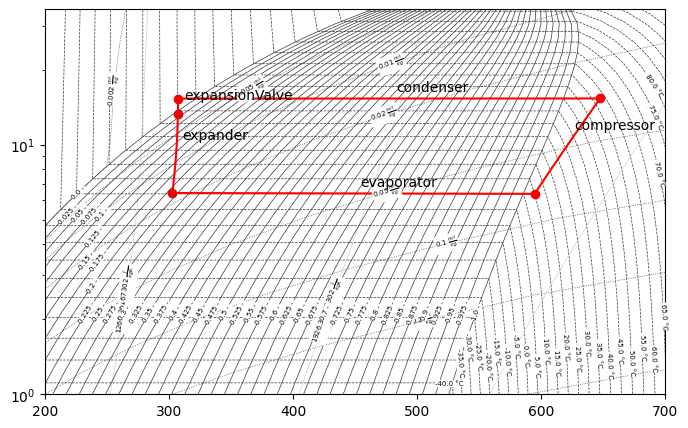

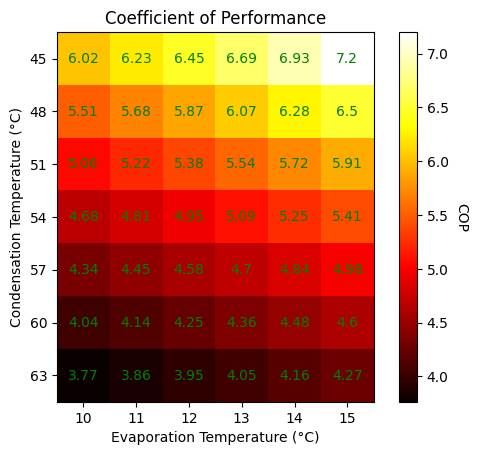

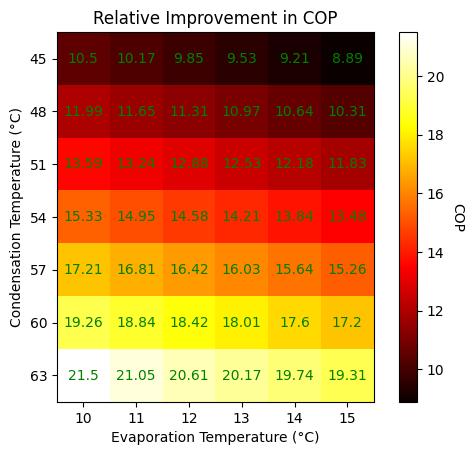

In [8]:
from HaierAirConditioner import AirConditionerStudy

recovery_AC = AirConditionerStudy(working_fluid=wf, Q_in=8e3, expansion_device="expander"
                                ).set_boundary_conditions(T_cond=45, T_evap=10).solve()
if enable_fluid_diagrams:
    recovery_AC.plot_ts_diag("output/recovery_AC_ts_diagram", x_min=1200, x_max=2600, y_min=-35, y_max=100)
    recovery_AC.plot_logph_diag("output/recovery_AC_logph_diagram", x_min = 200, x_max=700, y_min=1, y_max=35)

recovery_efficiency_matrix = recovery_AC.efficiency_matrix(ac_evaporator_range, ac_condenser_range)
recovery_AC.plot_efficiency("output/recovery_AC_efficiency_matrix", ac_evaporator_range, ac_condenser_range, recovery_efficiency_matrix)
relative_efficiency_matrix = recovery_AC.plot_relative_efficiency("output/recovery_AC_relative_efficiency", regular_efficiency_matrix, ac_evaporator_range, ac_condenser_range)



# Regular Heat Pump for comparison

(<Axes: title={'center': 'Coefficient of Performance'}, xlabel='Evaporation Temperature (°C)', ylabel='Condensation Temperature (°C)'>,
 <Figure size 640x480 with 2 Axes>)

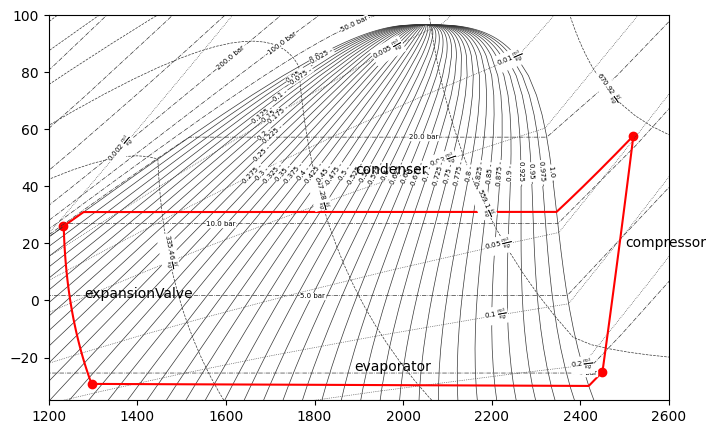

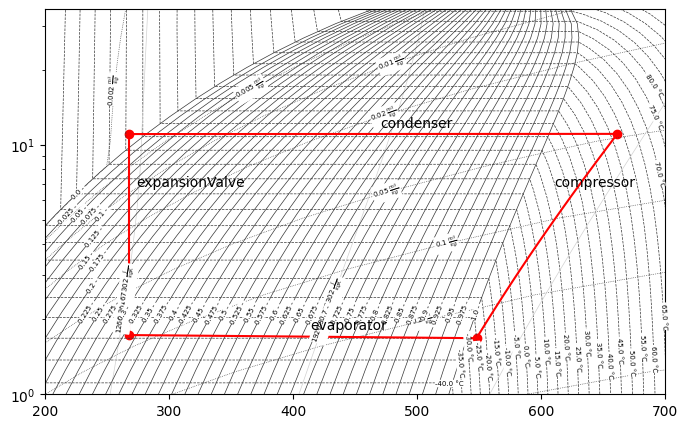

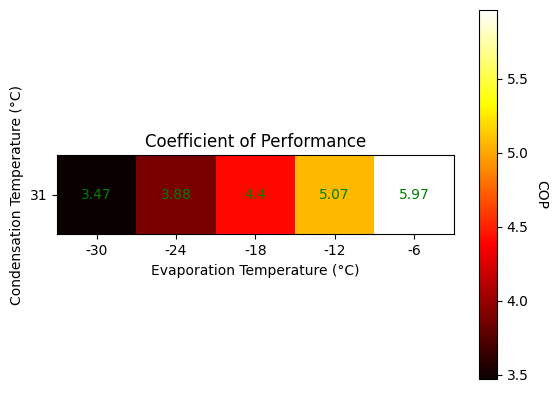

In [9]:
from HaierHeatPump import HeatPumpStudy

regular_HP = HeatPumpStudy(working_fluid=wf, Q_out=8e3
                                ).set_boundary_conditions(T_cond=hp_condenser_range[0], T_evap=hp_evaporator_range[0]).solve()
if enable_fluid_diagrams:
    regular_HP.plot_ts_diag("output/regular_HP_ts_diagram", x_min=1200, x_max=2600, y_min=-35, y_max=100)
    regular_HP.plot_logph_diag("output/regular_HP_logph_diagram", x_min = 200, x_max=700, y_min=1, y_max=35)

regular_efficiency_matrix = regular_HP.efficiency_matrix(hp_evaporator_range, hp_condenser_range)
regular_HP.plot_efficiency("output/regular_HP_efficiency_matrix", hp_evaporator_range, hp_condenser_range, regular_efficiency_matrix)


# Energy Recovery Study

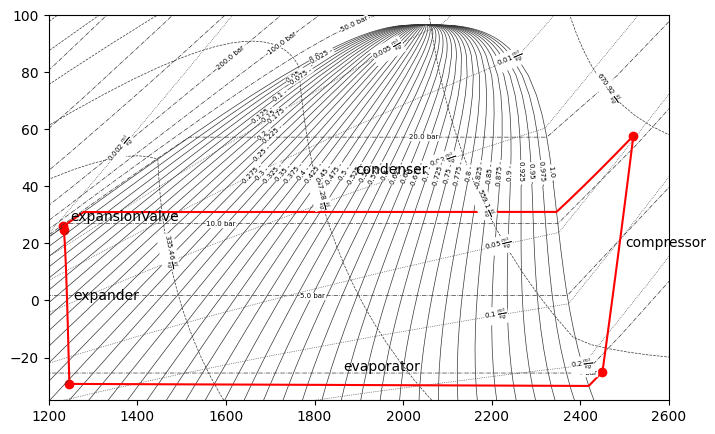

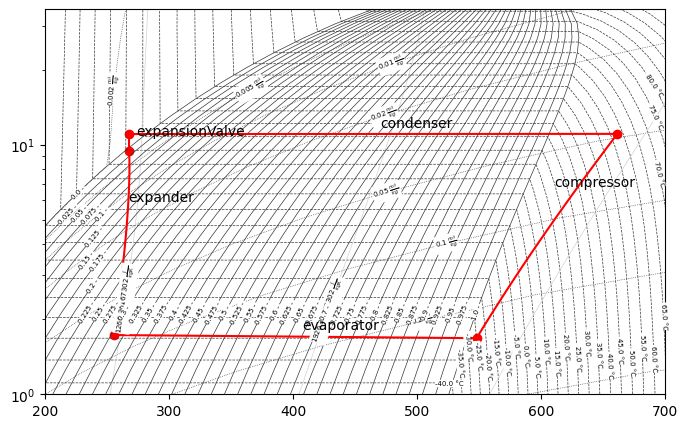

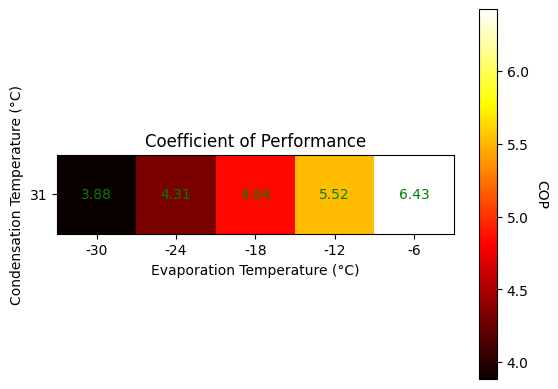

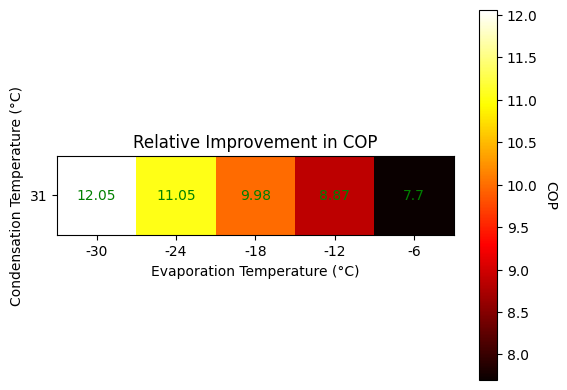

In [10]:
from HaierHeatPump import HeatPumpStudy

recovery_HP = HeatPumpStudy(working_fluid=wf, Q_out=8e3, expansion_device="expander"
                                ).set_boundary_conditions(T_cond=hp_condenser_range[0], T_evap=hp_evaporator_range[0]).solve()
if enable_fluid_diagrams:
    recovery_HP.plot_ts_diag("output/recovery_hp_ts_diagram", x_min=1200, x_max=2600, y_min=-35, y_max=100)
    recovery_HP.plot_logph_diag("output/recovery_hp_logph_diagram", x_min = 200, x_max=700, y_min=1, y_max=35)

recovery_efficiency_matrix = recovery_HP.efficiency_matrix(hp_evaporator_range, hp_condenser_range)
recovery_HP.plot_efficiency("output/recovery_hp_efficiency_matrix", hp_evaporator_range, hp_condenser_range, recovery_efficiency_matrix)
relative_efficiency_matrix = recovery_HP.plot_relative_efficiency("output/recovery_hp_relative_efficiency", regular_efficiency_matrix, hp_evaporator_range, hp_condenser_range)
